In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from google.colab import drive
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
data_path = "/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET"

log_files = glob.glob(data_path + "/mHealth_subject*.log")

print("파일 목록:")
for f in log_files:
    print(f)


파일 목록:
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject3.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject4.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject10.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject2.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject1.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject8.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject7.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject6.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject5.log
/content/drive/MyDrive/Colab Notebooks/MHEALTHDATASET/mHealth_subject9.log


In [27]:
# 각 파일을 데이터프레임으로 읽어 리스트에 저장합니다.
all_data_frames = []
for file_path in log_files:
    df = pd.read_csv(file_path, sep='\t', header=None)

    match = re.search(r'subject(\d+)', file_path)
    if match:
        subject_id = int(match.group(1))

        df['subject'] = subject_id
        all_data_frames.append(df)

# 모든 데이터프레임을 하나로 통합
df = pd.concat(all_data_frames, ignore_index=True)



df.head()



,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,subject
0,-9.4674,0.13721,1.0545,0.23862,-0.033490,-0.18848,-9.8425,0.90183,0.55659,-0.83490,...,2.0431,1.3105,-0.75490,-0.22998,0.78233,-1.605100,1.0685,-3.65290,0,3
1,-9.5991,0.15481,1.1824,0.22606,-0.079540,-0.36263,-9.7832,0.89263,0.55659,-0.83490,...,1.8242,1.4245,-0.75490,-0.22998,0.78233,-2.101500,5.2904,0.62709,0,3
2,-9.8612,0.13317,1.0646,0.20513,-0.096285,-0.24823,-9.8010,1.09080,0.57885,-0.84615,...,2.4401,1.0074,-0.75490,-0.22998,0.78233,0.565620,2.7021,-1.45980,0,3
3,-9.6398,0.17406,1.2367,0.18420,-0.062794,-0.25027,-9.6730,1.01380,0.57885,-0.84615,...,1.9019,1.1888,-0.75490,-0.22998,0.78233,0.244770,6.5233,-0.78236,0,3
4,-10.0360,0.26062,1.2761,0.12559,-0.025118,-0.20668,-9.9102,1.05450,0.57885,-0.84615,...,2.0140,1.4028,-0.75294,-0.22998,0.76293,0.034368,3.4368,-1.11670,0,3


In [28]:
column_names = [
    'acc_ch_x', 'acc_ch_y', 'acc_ch_z', # Chest Accelerometer
    'ecg_1', 'ecg_2',                  # Electrocardiogram
    'acc_la_x', 'acc_la_y', 'acc_la_z', # Left-Ankle Accelerometer
    'gyr_la_x', 'gyr_la_y', 'gyr_la_z', # Left-Ankle Gyroscope
    'mag_la_x', 'mag_la_y', 'mag_la_z', # Left-Ankle Magnetometer
    'acc_rw_x', 'acc_rw_y', 'acc_rw_z', # Right-Wrist Accelerometer
    'gyr_rw_x', 'gyr_rw_y', 'gyr_rw_z', # Right-Wrist Gyroscope
    'mag_rw_x', 'mag_rw_y', 'mag_rw_z', # Right-Wrist Magnetometer
    'activity',
    'subject'
]

df.columns = column_names
# 결과 확인
df

,acc_ch_x,acc_ch_y,acc_ch_z,ecg_1,ecg_2,acc_la_x,acc_la_y,acc_la_z,gyr_la_x,gyr_la_y,...,acc_rw_y,acc_rw_z,gyr_rw_x,gyr_rw_y,gyr_rw_z,mag_rw_x,mag_rw_y,mag_rw_z,activity,subject
0,-9.4674,0.13721,1.054500,0.23862,-0.033490,-0.18848,-9.8425,0.90183,0.556590,-0.83490,...,2.0431,1.3105,-0.75490,-0.22998,0.78233,-1.605100,1.0685,-3.65290,0,3
1,-9.5991,0.15481,1.182400,0.22606,-0.079540,-0.36263,-9.7832,0.89263,0.556590,-0.83490,...,1.8242,1.4245,-0.75490,-0.22998,0.78233,-2.101500,5.2904,0.62709,0,3
2,-9.8612,0.13317,1.064600,0.20513,-0.096285,-0.24823,-9.8010,1.09080,0.578850,-0.84615,...,2.4401,1.0074,-0.75490,-0.22998,0.78233,0.565620,2.7021,-1.45980,0,3
3,-9.6398,0.17406,1.236700,0.18420,-0.062794,-0.25027,-9.6730,1.01380,0.578850,-0.84615,...,1.9019,1.1888,-0.75490,-0.22998,0.78233,0.244770,6.5233,-0.78236,0,3
4,-10.0360,0.26062,1.276100,0.12559,-0.025118,-0.20668,-9.9102,1.05450,0.578850,-0.84615,...,2.0140,1.4028,-0.75294,-0.22998,0.76293,0.034368,3.4368,-1.11670,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,-12.2440,-2.97060,-0.035772,0.81214,1.096800,0.57061,-2.5602,0.41936,-0.055659,0.64165,...,-16.9660,2.3704,0.10980,-0.99384,0.19181,-6.128700,15.4950,18.85600,0,9
1215741,-10.9220,-3.41900,-0.339280,1.46940,1.285200,5.26840,-4.9331,9.66020,-0.055659,0.64165,...,-13.3900,2.9972,0.10980,-0.99384,0.19181,-10.242000,17.1390,33.92000,0,9
1215742,-9.4842,-3.06430,-1.033700,0.23862,0.891680,0.53805,-5.9706,2.93600,-0.055659,0.64165,...,-11.3790,3.1498,0.10980,-0.99384,0.19181,-12.944000,16.1700,43.26200,0,9
1215743,-8.7889,-2.47570,-0.612290,-0.20513,0.460490,1.56950,-7.9809,-2.05000,-0.085343,0.43715,...,-10.0000,3.0000,0.11961,-0.97331,0.15302,-14.524000,1.8494,43.37300,0,9


In [29]:
df.columns

Index(['acc_ch_x', 'acc_ch_y', 'acc_ch_z', 'ecg_1', 'ecg_2', 'acc_la_x',
       'acc_la_y', 'acc_la_z', 'gyr_la_x', 'gyr_la_y', 'gyr_la_z', 'mag_la_x',
       'mag_la_y', 'mag_la_z', 'acc_rw_x', 'acc_rw_y', 'acc_rw_z', 'gyr_rw_x',
       'gyr_rw_y', 'gyr_rw_z', 'mag_rw_x', 'mag_rw_y', 'mag_rw_z', 'activity',
       'subject'],
      dtype='object')

In [30]:
df.isnull().sum()

,0
acc_ch_x,0
acc_ch_y,0
acc_ch_z,0
ecg_1,0
ecg_2,0
acc_la_x,0
acc_la_y,0
acc_la_z,0
gyr_la_x,0
gyr_la_y,0


In [31]:
df['subject'].value_counts()

,count
subject,
1,161280
9,135168
2,130561
8,129024
3,122112
5,119808
4,116736
7,104448
10,98304


In [32]:
print("## 'activity' 컬럼의 값 분포")
print(df['activity'].value_counts())

## 'activity' 컬럼의 값 분포
activity
0     872550
1      30720
2      30720
3      30720
4      30720
9      30720
5      30720
11     30720
10     30720
7      29441
8      29337
6      28315
12     10342
Name: count, dtype: int64


In [33]:
df.shape

(1215745, 25)

In [34]:
X = df.drop(['subject', 'activity'], axis=1)
y = df['activity']

In [35]:
# 1. LabelEncoder 객체를 생성합니다.
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
window_size = 128
step = 64


window_size = 128
step = 64
X_windows, y_windows = [], []

# 윈도우 생성 루프
for i in range(0, len(X_scaled) - window_size, step):

    window = X_scaled[i : i + window_size]
    label_vector = y_encoded[i : i + window_size]

   #최빈값
    most_common_label = np.argmax(np.bincount(label_vector))

    X_windows.append(window)
    y_windows.append(most_common_label)

# 리스트를 Numpy 배열로 변환
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

# 결과 확인
print("생성된 X 데이터 형태:", X_windows.shape)
print("생성된 y 데이터 형태:", y_windows.shape)

생성된 X 데이터 형태: (18995, 128, 23)
생성된 y 데이터 형태: (18995,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=42, stratify=y_windows
)


## 모델 구축 및 훈련

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout


n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
n_outputs = len(np.unique(y_train))


model = Sequential([

    Conv1D(filters=64, kernel_size=3, activation='relu',
           padding='same', input_shape=(n_timesteps, n_features)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(80, activation='relu'),
    Dropout(0.3),

    Dense(n_outputs, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 128, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │         2,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         1,053 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,701 (369.93 KB)

 Trainable params: 94,701 (369.93 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:

# 모델 훈련
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6882 - loss: 1.4240 - val_accuracy: 0.7294 - val_loss: 0.7079
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7416 - loss: 0.6703 - val_accuracy: 0.8071 - val_loss: 0.4273
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7888 - loss: 0.4581 - val_accuracy: 0.8289 - val_loss: 0.3522
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8027 - loss: 0.3947 - val_accuracy: 0.8360 - val_loss: 0.3346
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8229 - loss: 0.3714 - val_accuracy: 0.8636 - val_loss: 0.2987
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8500 - loss: 0.3159 - val_accuracy: 0.8652 - val_loss: 0.3283
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8499 - loss: 0.3211 - val_accuracy: 0.8758 - val_loss: 0.2739
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8662 - loss: 0.2994 - val_accu

In [41]:
def plot_history(history):
    plt.figure(figsize=(10, 8))
    sns.set_theme()
    # --- 정확도 ---
    plt.subplot(2, 1, 1)
    plt.plot(history.history['accuracy'], 'r-', label='Train')
    plt.plot(history.history['val_accuracy'], 'b-', label='Val')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # --- 손실 ---
    plt.subplot(2, 1, 2)
    plt.plot(history.history['loss'], 'r-', label='Train')
    plt.plot(history.history['val_loss'], 'b-', label='Val')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

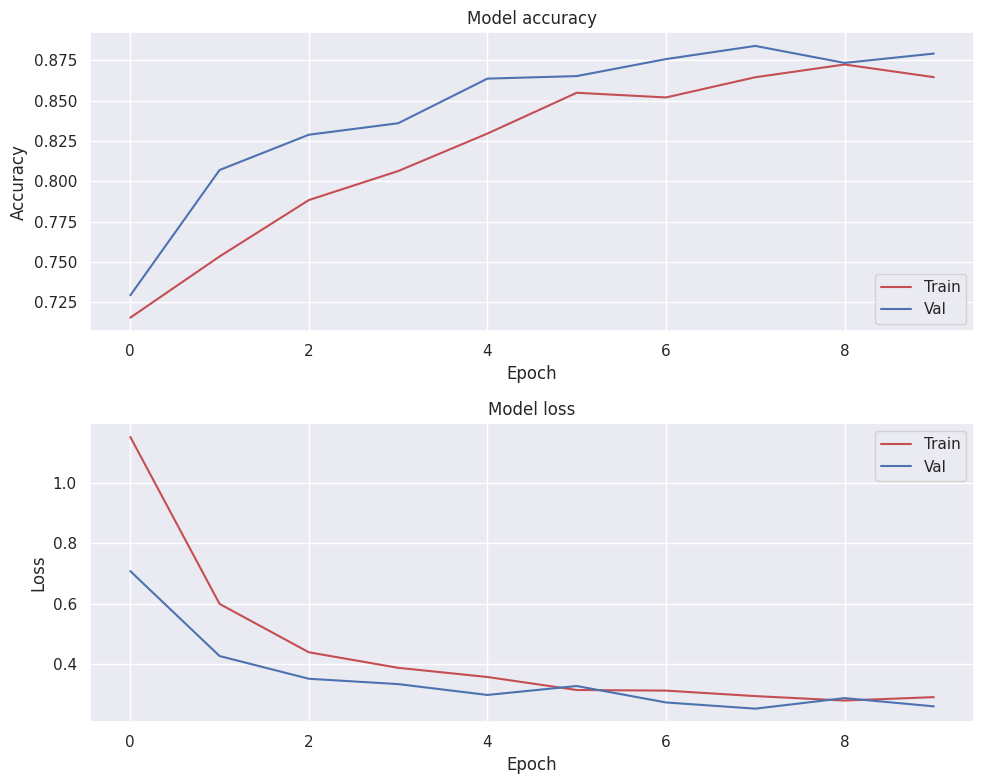

In [42]:
plot_history(history)

In [43]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)


y_pred = np.argmax(y_pred_probs, axis=1)


y_true = y_test

# --- 2. 최종 결과 출력 ---
print("\n[ 분류 보고서 (Classification Report) ]")
print(classification_report(y_true, y_pred))

print("\n[ 혼동 행렬 (Confusion Matrix) ]")
print(confusion_matrix(y_true, y_pred))

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

[ 분류 보고서 (Classification Report) ]
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      2736
           1       0.59      0.99      0.74        95
           2       0.65      1.00      0.79        95
           3       0.73      1.00      0.84        95
           4       0.83      0.99      0.90        95
           5       0.76      0.96      0.85        95
           6       0.58      1.00      0.73        88
           7       0.68      1.00      0.81        91
           8       0.69      0.96      0.80        92
           9       0.83      0.94      0.88        95
          10       0.76      1.00      0.86        95
          11       0.78      0.96      0.86        95
          12       0.54      1.00      0.70        32

    accuracy                           0.88      3799
   macro avg       0.72      0.97      0.82      3799
weighted avg       0.92      0.88      0.89      3799


[

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 1. 점수 계산
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

# 2. 출력
print("="*50)
print("최종 평가 점수")
print("="*50)
print(f"Accuracy Score : {acc}")
print(f"Precision Score: {prec}")
print(f"Recall Score   : {rec}")
print(f"F1 Score       : {f1}")

최종 평가 점수
Accuracy Score : 0.8791787312450645
Precision Score: 0.9157490874689079
Recall Score   : 0.8791787312450645
F1 Score       : 0.8857011271712536


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 최종 평가 요약 + 혼동 행렬 시각화 함수
def results_summarizer(y_true, y_pred):
    """
    분류 모델의 평가 지표와 혼동 행렬을 계산하고 시각화하는 함수.

    Args:
        y_true (array): 실제 정답 레이블 (숫자 형태)
        y_pred (array): 모델의 예측 레이블 (숫자 형태)
    """

    # 1. 평가 지표 계산
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print("="*50)
    print("최종 평가 점수")
    print("="*50)
    print(f"Accuracy Score : {acc:.4f}")
    print(f"Precision Score: {prec:.4f}")
    print(f"Recall Score   : {rec:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    # 2. 활동 이름 매핑 (MHEALTH 13개 전체 활동)
    activity_map = {
        0: 'Null',
        1: 'Standing still',
        2: 'Sitting and relaxing',
        3: 'Lying down',
        4: 'Walking',
        5: 'Climbing stairs',
        6: 'Waist bends forward',
        7: 'Frontal elevation of arms',
        8: 'Knees bending (crouching)',
        9: 'Cycling',
        10: 'Jogging',
        11: 'Running',
        12: 'Jump front & back'
    }

    # 3. 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)

    # 4. 혼동 행렬 시각화
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(activity_map.values()),
        yticklabels=list(activity_map.values())
    )
    plt.title('Confusion Matrix', fontsize=20)
    plt.xlabel('Predicted Activity', fontsize=14)
    plt.ylabel('Actual Activity', fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
최종 평가 점수
Accuracy Score : 0.8792
Precision Score: 0.9157
Recall Score   : 0.8792
F1 Score       : 0.8857


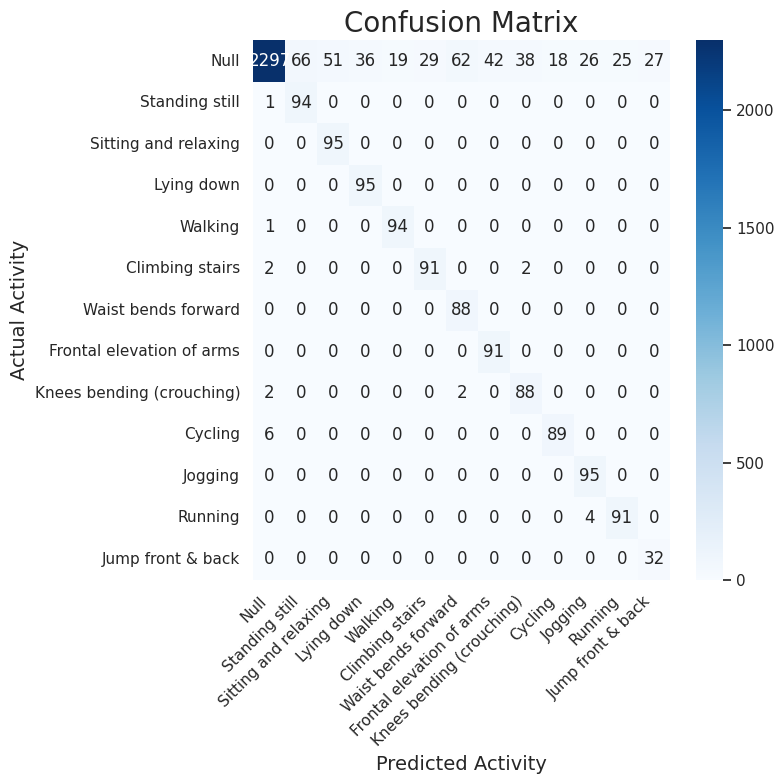

In [46]:

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.array(y_test).ravel()
results_summarizer(y_true, y_pred)
